# Desafio Final: Análise Financeira com Python

**ClearBank** — Notebook para leitura, validação e análise de transações bancárias.

## Instruções
- O arquivo `transacoes.csv` deve estar na mesma pasta deste notebook.
- Execute as células em ordem, da primeira à última.
- A célula principal ao final gera `relatorio.json` e exibe o relatório no terminal.

O CSV contém **18 registros válidos** em 4 meses, **5 registros inválidos** e **2 transações acima de R$ 10.000,00**.

In [1]:
import csv
import json
from datetime import datetime

LIMITE_SUSPEITO = 10000.00
ARQUIVO_CSV = "transacoes.csv"
ARQUIVO_JSON = "relatorio.json"

print("Constantes e imports carregados.")
print(f"Limite para transações suspeitas: R$ {LIMITE_SUSPEITO:,.2f}")

Constantes e imports carregados.
Limite para transações suspeitas: R$ 10,000.00


## R1 — Leitura do CSV com módulo nativo

In [2]:
def ler_transacoes(caminho: str) -> list[dict]:
    """Lê o arquivo CSV e retorna a lista de transações brutas."""
    transacoes = []
    try:
        with open(caminho, encoding="utf-8", newline="") as arquivo:
            leitor = csv.DictReader(arquivo)
            for linha in leitor:
                transacoes.append(dict(linha))
    except FileNotFoundError:
        print(f"Erro: arquivo '{caminho}' não encontrado.")
        return []
    return transacoes


brutas = ler_transacoes(ARQUIVO_CSV)
print(f"Linhas brutas lidas: {len(brutas)}")
print("Primeira transação:", brutas[0] if brutas else "Nenhuma")

Linhas brutas lidas: 23
Primeira transação: {'id': '1', 'data': '2026-01-05', 'cliente_id': 'CLI001', 'tipo': 'credito', 'valor': '3500.00', 'descricao': 'Salário janeiro', 'categoria': 'salario'}


## R2 — Validação e limpeza dos dados

In [3]:
def validar_transacao(linha: dict) -> dict | None:
    """Valida uma linha e retorna o registro limpo ou None se inválida."""
    id_texto = (linha.get("id") or "").strip()
    if not id_texto.isdigit():
        return None

    cliente_id = (linha.get("cliente_id") or "").strip()
    if not cliente_id:
        return None

    tipo = (linha.get("tipo") or "").strip().lower()
    if tipo not in ("credito", "debito"):
        return None

    try:
        valor = float(str(linha.get("valor", "")).strip().replace(",", "."))
        if valor <= 0:
            return None
    except ValueError:
        return None

    data_texto = (linha.get("data") or "").strip()
    try:
        data_obj = datetime.strptime(data_texto, "%Y-%m-%d")
    except ValueError:
        return None

    return {
        "id": int(id_texto),
        "data": data_obj,
        "data_texto": data_texto,
        "mes": data_obj.strftime("%Y-%m"),
        "cliente_id": cliente_id,
        "tipo": tipo,
        "valor": valor,
        "descricao": (linha.get("descricao") or "").strip(),
        "categoria": (linha.get("categoria") or "").strip(),
        "suspeita": valor > LIMITE_SUSPEITO,
    }


def limpar_transacoes(brutas: list[dict]) -> tuple[list[dict], int, int]:
    """Retorna transações válidas, total lidas e total inválidas."""
    validas = []
    invalidas = 0
    for linha in brutas:
        registro = validar_transacao(linha)
        if registro is None:
            invalidas += 1
        else:
            validas.append(registro)
    return validas, len(brutas), invalidas


validas, total_lidas, total_invalidas = limpar_transacoes(brutas)
print(f"Total de linhas lidas: {total_lidas}")
print(f"Linhas válidas: {len(validas)}")
print(f"Linhas inválidas: {total_invalidas}")

Total de linhas lidas: 23
Linhas válidas: 18
Linhas inválidas: 5


## R4 — Manipulação de datas

In [4]:
def calcular_periodo(transacoes: list[dict]) -> dict:
    """Calcula data mais antiga, mais recente e dias entre elas."""
    if not transacoes:
        return {"inicio": None, "fim": None, "dias": 0}

    datas = [t["data"] for t in transacoes]
    inicio = min(datas)
    fim = max(datas)
    dias = (fim - inicio).days
    return {
        "inicio": inicio.strftime("%Y-%m-%d"),
        "fim": fim.strftime("%Y-%m-%d"),
        "dias": dias,
    }


periodo = calcular_periodo(validas)
print(f"Período: {periodo['inicio']} → {periodo['fim']}")
print(f"Dias entre a transação mais antiga e a mais recente: {periodo['dias']}")

Período: 2026-01-05 → 2026-04-15
Dias entre a transação mais antiga e a mais recente: 100


## R5 — Agrupamento mensal e métricas

In [5]:
def gerar_relatorio(transacoes: list[dict], total_invalidas: int) -> dict:
    """Agrupa os dados por mês e calcula métricas financeiras."""
    resumo_mensal = {}
    suspeitas = []

    for t in transacoes:
        mes = t["mes"]
        if mes not in resumo_mensal:
            resumo_mensal[mes] = {
                "quantidade": 0,
                "total_credito": 0.0,
                "total_debito": 0.0,
                "valores": [],
            }

        resumo_mensal[mes]["quantidade"] += 1
        resumo_mensal[mes]["valores"].append(t["valor"])

        if t["tipo"] == "credito":
            resumo_mensal[mes]["total_credito"] += t["valor"]
        else:
            resumo_mensal[mes]["total_debito"] += t["valor"]

        if t["suspeita"]:
            suspeitas.append({
                "id": t["id"],
                "cliente_id": t["cliente_id"],
                "data": t["data_texto"],
                "valor": t["valor"],
            })

    for mes, dados in resumo_mensal.items():
        valores = dados.pop("valores")
        dados["saldo"] = round(dados["total_credito"] - dados["total_debito"], 2)
        dados["valor_medio"] = round(sum(valores) / len(valores), 2)
        dados["maior_valor"] = round(max(valores), 2)
        dados["menor_valor"] = round(min(valores), 2)
        dados["total_credito"] = round(dados["total_credito"], 2)
        dados["total_debito"] = round(dados["total_debito"], 2)

    periodo_info = calcular_periodo(transacoes)

    return {
        "gerado_em": datetime.now().strftime("%Y-%m-%d"),
        "total_transacoes_validas": len(transacoes),
        "total_transacoes_invalidas": total_invalidas,
        "periodo": periodo_info,
        "resumo_mensal": dict(sorted(resumo_mensal.items())),
        "transacoes_suspeitas": suspeitas,
    }


relatorio = gerar_relatorio(validas, total_invalidas)
print("Meses analisados:", list(relatorio["resumo_mensal"].keys()))
print("Transações suspeitas:", len(relatorio["transacoes_suspeitas"]))

Meses analisados: ['2026-01', '2026-02', '2026-03', '2026-04']
Transações suspeitas: 2


## R7 — Exportação do relatório em JSON

In [6]:
def salvar_json(dados: dict, caminho: str) -> None:
    """Salva o relatório no arquivo JSON."""
    with open(caminho, "w", encoding="utf-8") as arquivo:
        json.dump(dados, arquivo, ensure_ascii=False, indent=2)
    print(f"Relatório salvo em '{caminho}'.")


salvar_json(relatorio, ARQUIVO_JSON)

Relatório salvo em 'relatorio.json'.


## R8 — Exibição formatada no terminal

In [7]:
def formatar_moeda(valor: float) -> str:
    """Formata valor no padrão monetário brasileiro."""
    return f"R$ {valor:,.2f}".replace(",", "X").replace(".", ",").replace("X", ".")


def exibir_relatorio(dados: dict) -> None:
    """Formata e imprime os resultados no terminal."""
    periodo = dados["periodo"]
    print("=" * 30)
    print(" RESUMO DA ANÁLISE")
    print("=" * 30)
    print(f"Período analisado: {periodo['inicio']} → {periodo['fim']}")
    print(f"Dias no período: {periodo['dias']}")
    print(f"Transações válidas: {dados['total_transacoes_validas']}")
    print(f"Transações inválidas: {dados['total_transacoes_invalidas']}")
    print()
    print("===== RELATÓRIO MENSAL =====")
    print()

    for mes, info in dados["resumo_mensal"].items():
        print(f"Mês: {mes}")
        print(f"  Transações: {info['quantidade']}")
        print(f"  Total crédito: {formatar_moeda(info['total_credito'])}")
        print(f"  Total débito:  {formatar_moeda(info['total_debito'])}")
        print(f"  Saldo:         {formatar_moeda(info['saldo'])}")
        print(f"  Média:         {formatar_moeda(info['valor_medio'])}")
        print(f"  Maior valor:   {formatar_moeda(info['maior_valor'])}")
        print(f"  Menor valor:   {formatar_moeda(info['menor_valor'])}")
        print()

    print("===== TRANSAÇÕES SUSPEITAS =====")
    if dados["transacoes_suspeitas"]:
        for t in dados["transacoes_suspeitas"]:
            print(
                f"ID: {t['id']} | Cliente: {t['cliente_id']} | "
                f"Data: {t['data']} | Valor: {formatar_moeda(t['valor'])}"
            )
    else:
        print("Nenhuma transação suspeita encontrada.")


exibir_relatorio(relatorio)

 RESUMO DA ANÁLISE
Período analisado: 2026-01-05 → 2026-04-15
Dias no período: 100
Transações válidas: 18
Transações inválidas: 5

===== RELATÓRIO MENSAL =====

Mês: 2026-01
  Transações: 5
  Total crédito: R$ 7.700,00
  Total débito:  R$ 520,40
  Saldo:         R$ 7.179,60
  Média:         R$ 1.644,08
  Maior valor:   R$ 4.200,00
  Menor valor:   R$ 89,90

Mês: 2026-02
  Transações: 5
  Total crédito: R$ 27.000,00
  Total débito:  R$ 845,00
  Saldo:         R$ 26.155,00
  Média:         R$ 5.569,00
  Maior valor:   R$ 15.000,00
  Menor valor:   R$ 75,00

Mês: 2026-03
  Transações: 6
  Total crédito: R$ 4.300,00
  Total débito:  R$ 1.534,40
  Saldo:         R$ 2.765,60
  Média:         R$ 972,40
  Maior valor:   R$ 3.500,00
  Menor valor:   R$ 35,50

Mês: 2026-04
  Transações: 2
  Total crédito: R$ 2.800,00
  Total débito:  R$ 550,00
  Saldo:         R$ 2.250,00
  Média:         R$ 1.675,00
  Maior valor:   R$ 2.800,00
  Menor valor:   R$ 550,00

===== TRANSAÇÕES SUSPEITAS =====
ID: 5 

## Célula de Execução Principal

In [8]:
def executar_analise() -> dict:
    """Executa o fluxo completo da análise financeira."""
    brutas = ler_transacoes(ARQUIVO_CSV)
    if not brutas:
        return {}

    validas, total_lidas, total_invalidas = limpar_transacoes(brutas)
    print(f"Total de linhas lidas: {total_lidas}")
    print(f"Linhas válidas: {len(validas)}")
    print(f"Linhas inválidas: {total_invalidas}")
    print()

    relatorio_final = gerar_relatorio(validas, total_invalidas)
    salvar_json(relatorio_final, ARQUIVO_JSON)
    exibir_relatorio(relatorio_final)
    return relatorio_final


resultado_final = executar_analise()

Total de linhas lidas: 23
Linhas válidas: 18
Linhas inválidas: 5

Relatório salvo em 'relatorio.json'.
 RESUMO DA ANÁLISE
Período analisado: 2026-01-05 → 2026-04-15
Dias no período: 100
Transações válidas: 18
Transações inválidas: 5

===== RELATÓRIO MENSAL =====

Mês: 2026-01
  Transações: 5
  Total crédito: R$ 7.700,00
  Total débito:  R$ 520,40
  Saldo:         R$ 7.179,60
  Média:         R$ 1.644,08
  Maior valor:   R$ 4.200,00
  Menor valor:   R$ 89,90

Mês: 2026-02
  Transações: 5
  Total crédito: R$ 27.000,00
  Total débito:  R$ 845,00
  Saldo:         R$ 26.155,00
  Média:         R$ 5.569,00
  Maior valor:   R$ 15.000,00
  Menor valor:   R$ 75,00

Mês: 2026-03
  Transações: 6
  Total crédito: R$ 4.300,00
  Total débito:  R$ 1.534,40
  Saldo:         R$ 2.765,60
  Média:         R$ 972,40
  Maior valor:   R$ 3.500,00
  Menor valor:   R$ 35,50

Mês: 2026-04
  Transações: 2
  Total crédito: R$ 2.800,00
  Total débito:  R$ 550,00
  Saldo:         R$ 2.250,00
  Média:         R$ 1.

## RO1 (Opcional) — Visualização com matplotlib

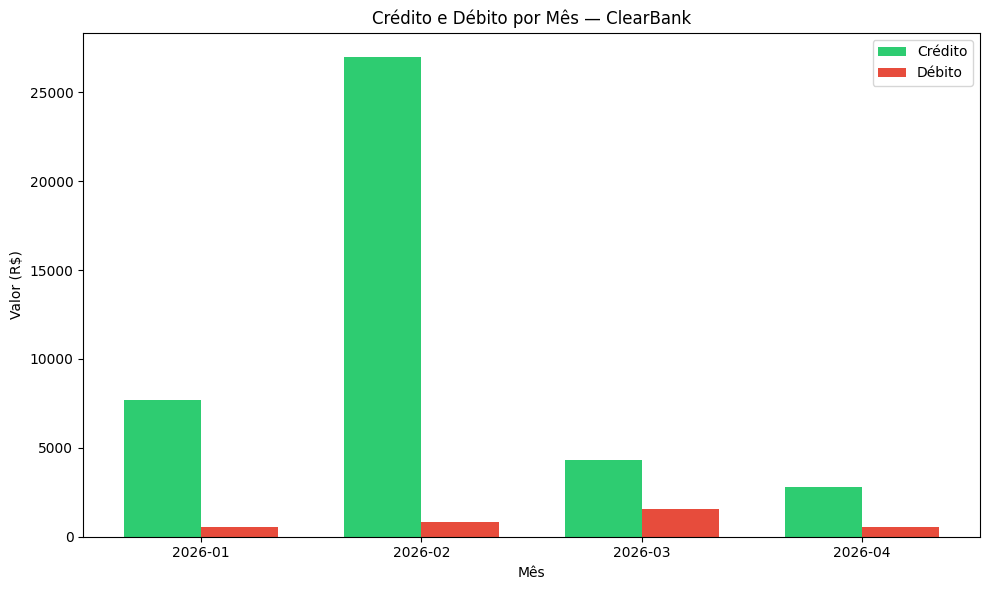

Gráfico salvo em grafico.png


In [9]:
import matplotlib.pyplot as plt

meses = list(relatorio["resumo_mensal"].keys())
creditos = [relatorio["resumo_mensal"][m]["total_credito"] for m in meses]
debitos = [relatorio["resumo_mensal"][m]["total_debito"] for m in meses]
saldos = [relatorio["resumo_mensal"][m]["saldo"] for m in meses]

fig, ax = plt.subplots(figsize=(10, 6))
x = range(len(meses))
largura = 0.35
ax.bar([i - largura / 2 for i in x], creditos, largura, label="Crédito", color="#2ecc71")
ax.bar([i + largura / 2 for i in x], debitos, largura, label="Débito", color="#e74c3c")
ax.set_title("Crédito e Débito por Mês — ClearBank")
ax.set_xlabel("Mês")
ax.set_ylabel("Valor (R$)")
ax.set_xticks(list(x))
ax.set_xticklabels(meses)
ax.legend()
plt.tight_layout()
plt.savefig("grafico.png", dpi=150)
plt.show()
print("Gráfico salvo em grafico.png")